# CodeS over NL2RepoBench: what the three-stage pipeline scored, and what it consumed

Job `2026-09-07__00-40-22` is 104 trials — every task in the benchmark, once each, one
model, and a pipeline rather than a loop. A **RepoSketcher** turns the specification
into a file tree. A **FileSketcher** turns each file into a skeleton of signatures. A
**SketchFiller** then writes the body of every function in that skeleton, one request
per function, forty at a time. There is no feedback: nothing runs the code, and nothing
comes back to revise a stage once it is done.

The budget is not a turn count or a reply length but a **token budget** — four million
tokens for the whole pipeline — with a wall-clock limit beside it. Most of what follows
is about what happens when a pipeline that cannot revise itself decides, up front, how
much work to do.

This notebook reads the job directory as it stands on disk and asks:

1. **What did it score?** — the reward distribution, and how it moves with difficulty.
2. **Did the pipeline finish?** — where it stopped, and what decided that.
3. **What did the tokens buy?** — tokens per trial against reward earned.
4. **How did the zeros happen?** — a zero from failing tests and a zero from an
   unimportable package are different findings, and the verifier logs tell them apart.

Nothing here is re-run or re-scored; every number is read from the files the job wrote.
This is the fourth of four run notebooks that share a reader and a set of figures, and
it makes **no comparison between the arms** — that is a separate exercise now that every
arm has been run.

## 1. Parameters

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# --- what to read ------------------------------------------------------------
JOB = "2026-09-07__00-40-22"

# Reward at or above which a task counts as solved rather than partially credited.
# Not 1.0: a run that passes 95% of a package's hidden tests has produced a working
# package, and calling that a failure would flatter every method equally. Every
# other threshold this notebook uses is a budget, and those are read from each
# trial's own configuration rather than restated here.
SOLVED_AT = 0.9

# Figures are prefixed so the arms' figures sit beside each other in docs/figures
# without overwriting one another.
FIGURE_PREFIX = "codes"

# `job_analysis` and `job_figures` live beside the notebooks. Jupyter puts the
# notebook's own directory on the path; this covers a kernel started elsewhere.
NOTEBOOKS = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
if str(NOTEBOOKS) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS))

import matplotlib.pyplot as plt

import job_analysis as ja
import job_figures as jf

jf.use_house_style()
save = jf.saver(FIGURE_PREFIX)

df = ja.load_job(JOB, solved_at=SOLVED_AT)
print(f"job     : {ja.job_path(JOB)}")
print(f"arm     : {df.attrs['arm'].name}")
print(f"budget  : {df.attrs['arm'].budget_name} = {df.attrs['budget']}")
print(f"solved  : reward >= {SOLVED_AT}")
print()
print(ja.headline(df))
print()
print(df.outcome.value_counts().to_string())

job     : C:\Code\EvaluationPlatform\jobs\2026-09-07__00-40-22
arm     : codes
budget  : max_token_budget = 4000000
solved  : reward >= 0.9

trials          : 104
mean reward     : 0.068   median 0.000   (n=104)
total tokens    : 408.7M  (58% of input served from cache)
total wall clock: 27.3 h summed over trials

outcome
never imported     60
partial credit     24
ran, all failed    13
no verdict          5
solved              2


## 2. Conventions

Two rules govern every figure, and both live in `job_figures` rather than being
restated per notebook.

**Ordered variables get ordered ramps.** Difficulty, token quartile and failure stage
are all ordered, so each gets one hue running light to dark rather than a set of
arbitrary colours. Where none of them is the subject, grey is context and blue is the
thing being shown; red is reserved for the one thing a figure is warning about.

**Text on a figure is a title, an axis word, and direct labels on the marks.** The
strings for the shared figures are in `jf.FIGURE_TEXT` and every one of them takes a
`text=` override, so re-wording a chart never means touching plotting code. Titles that
quote a number are format strings filled from the data at draw time, so they cannot go
stale when `JOB` changes. The cell below holds the same thing for the figures that only
this notebook draws.

In [2]:
import matplotlib.pyplot as plt

# The figures only this notebook draws. Everything else is `jf.FIGURE_TEXT`.
TEXT = {
    "endings": dict(
        title="{n_stopped} von {n} Läufen erreichen das Ende der Pipeline nie",
        x="eingeplante Funktionsrümpfe (log)", y="",
    ),
    "decomposition": dict(
        title="Wie fein zerlegt wird, liegt nicht an der Aufgabe",
        x="", y="eingeplante Funktionsrümpfe (log)", note="{rate:.0%} fertig",
    ),
    "deaths": dict(
        title="Woran die Läufe enden, und wann",
        x="Laufzeit des Agenten (min)", y="",
        row="{n} Läufe · {share} · mittlerer Reward {reward}",
        limits=("eigene Laufzeitgrenze\n{minutes} min",
                "Harness-Frist\n{minutes} min"),
    ),
}

## 3. Reading the job directory

`ja.load_job` returns one row per trial. Its shared half — reward, tokens,
timings, the pytest summary, and the reason behind every flat zero — is read the same
way for every arm, so a cause counted here means what it means in the other run
notebooks. `ja.COMMON_COLUMNS` is that contract; anything else on the frame is this
arm's own, listed in its `ja.ARMS` entry.

What this arm records on top comes from `agent/codes.log`, which prints one line per
file as the filler works through the sketch: `planned_files`, `files_reached`,
`function_prompts` (the number of function bodies queued for writing — the size of the
decomposition), `requests`, `completed`, `stop_limit`, and `unparseable`, the count of
filled sketches that came back as code Python could not parse.

Only that log is read. The three `agent/codes/*.jsonl` files beside it hold the full
prompt-and-response record of every stage and come to **3.4 GB** for this job alone; the
log carries the counts without any of it.

The budget here is `max_token_budget`, and `hit_budget` means the pipeline did not reach
its own `Done`. **Eight trials have no recorded usage at all** — they were killed before
the runner wrote its usage file — so `total_tok` is `NaN` for those, and every
consumption figure below is over the 96 trials that reported. All 104 were still graded,
so none of them is missing a reward.

## 4. What the run scored

Ranking every trial rather than binning them shows the shape of the distribution
without a choice of bin width doing any of the arguing.

wrote docs\figures\codes-reward-ranked.png


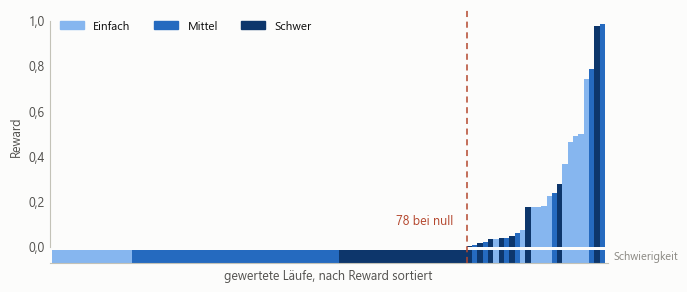

            trials at zero  scored trials  share of the level
difficulty                                                   
Easy                    15             26                0.58
Medium                  39             46                0.85
Hard                    24             32                0.75


In [3]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.reward_ranked(df), "reward-ranked")
plt.show()

print(ja.zero_rate(df).round(2).to_string())

Difficulty is the benchmark's own label, assigned from lines of code before any model
saw the task, so the gradient below is less a finding about this run than a check that
the run behaves the way the label says it should.

wrote docs\figures\codes-reward-by-difficulty.png


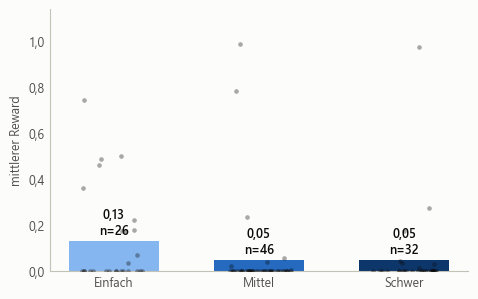

In [4]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.reward_by_difficulty(df), "reward-by-difficulty")
plt.show()

## 5. Where the pipeline stopped

The SketchFiller writes one function body per request, so the cost of a run is set by
how many function bodies the sketch asked for. That number is decided in the first two
stages, before a single body is written, and it is decided once — nothing later can
revise it downwards.

Plotting where each run stopped against the size of its own decomposition puts the
mechanism on one figure.

wrote docs\figures\codes-pipeline-endings.png


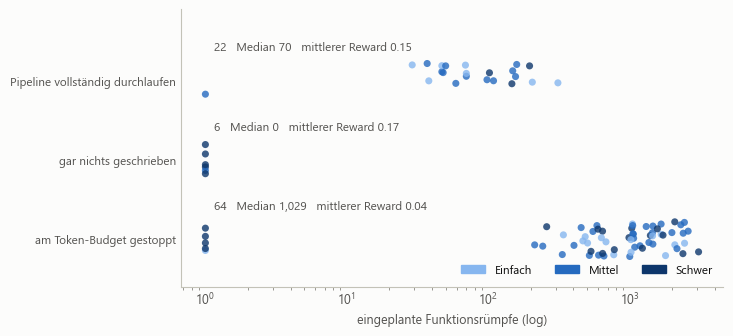

                                 trials  median_queued  files_written  requests  mean_reward
ending                                                                                      
finished the whole pipeline          22           70.0           10.0     108.0         0.15
killed by a signal                    2         3468.5            0.0      43.0         0.00
stopped at its own wall clock         4         1949.0           28.5      29.5         0.00
stopped at the harness deadline       6          438.5            0.0      29.5         0.00
stopped at the token budget          64         1029.0           18.0     172.5         0.04
wrote nothing at all                  6            0.0            0.0       1.0         0.17


In [5]:
import numpy as np

df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["endings"]

# Pipeline order: finished first, then the ways of not finishing.
ORDER = ["finished the whole pipeline", "wrote nothing at all",
         "stopped at the token budget", "stopped at the wall clock",
         "killed before it finished"]
order = [e for e in ORDER if e in set(df.ending)]
rng = np.random.default_rng(0)   # vertical jitter only

fig, ax = plt.subplots(figsize=(7.0, 3.6))
for i, ending in enumerate(order[::-1]):
    part = df[df.ending == ending]
    # A queue of zero is a real outcome — a sketch with no function bodies at
    # all — and cannot go on a log axis, so it sits at the left edge instead.
    queued = part.function_prompts.clip(lower=1)
    ax.scatter(
        queued, i + rng.uniform(-0.22, 0.22, len(part)),
        s=26, color=[jf.BAND_COLOR[d] for d in part.difficulty],
        alpha=0.8, linewidth=0, zorder=3,
    )
    ax.annotate(
        f"{len(part)}   Median {part.function_prompts.median():,.0f}"
        f"   mittlerer Reward {part.reward.mean():.2f}",
        xy=(1.15, i + 0.34), color=jf.INK_2, fontsize=8.5, va="bottom",
    )

stopped = int(df.hit_budget.sum())
ax.set_xscale("log")
jf.title(ax, t["title"], n_stopped=stopped, n=len(df))
ax.set_xlabel(t["x"])
ax.set_yticks(range(len(order)))
ax.set_yticklabels([jf.de(e) for e in order[::-1]], fontsize=8.5)
ax.set_ylim(-0.6, len(order) - 0.1)
jf.tidy(ax, grid_axis="x")
jf.difficulty_legend(ax, loc="lower right")
save(fig, "pipeline-endings")
plt.show()

print(df.groupby("ending").agg(
    trials=("reward", "size"), median_queued=("function_prompts", "median"),
    files_written=("workspace_files", "median"), requests=("requests", "median"),
    mean_reward=("reward", "mean")).round(2).to_string())

The separation is not subtle: the runs that finished had queued a median of about
seventy function bodies, the ones stopped at the token budget around a thousand. Almost
nothing overlaps.

**One row is not what it looks like.** Six runs print the pipeline's own `Done` after a
single request, having written *nothing at all* — the RepoSketcher returned no file tree,
so there was never anything for the later stages to fill. Counting those as finished
pipelines would flatter the arm, so they are broken out as `wrote nothing at all`, and
the check is the workspace itself rather than the log: `workspace_files == 0`.

That row carries a finding about the **benchmark**, not about CodeS. Five of those six
empty repositories score 0.00, as they should. The sixth, `more-Itertools`, scores
**0.978 — 667 of 682 hidden tests pass against a workspace containing no files**, because
that task's tests import the `more_itertools` already installed in the image rather than
the generated package. Self-Collaboration records the identical 0.978006 on the same
task. Across all four arms, exactly one trial scores above 0.5 with an empty workspace,
and it is this one. Any cross-arm comparison should treat `more-Itertools` as
ungradeable until its tester is fixed.

The obvious explanation would be that the big decompositions are the big tasks. They are
not. Splitting the same number by the benchmark's difficulty label gives three
distributions that sit on top of one another, and the share of runs that finish is
almost identical in each — so how finely CodeS decomposes a repository is a property of
its own sketch, not of the repository it was asked for.

wrote docs\figures\codes-decomposition.png


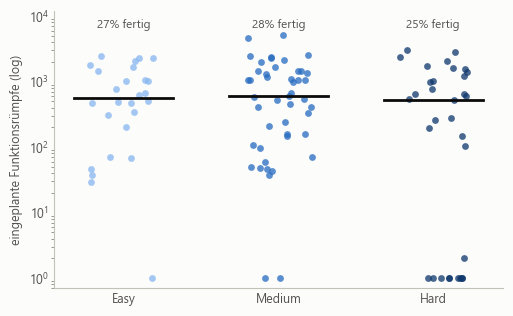

what the size of the decomposition tracks (Pearson r)
  words in the specification      : -0.19
  hidden tests in the task        : -0.14
  files the repo sketch planned   : +0.50

            trials  completed  completion_rate  median_queued
difficulty                                                   
Easy            26          7             0.27          567.5
Medium          46         13             0.28          595.0
Hard            32          8             0.25          530.0

filled sketches that would not parse: 175 across 63 of 104 trials


In [6]:
import numpy as np

df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["decomposition"]
rng = np.random.default_rng(0)   # jitter only

fig, ax = plt.subplots(figsize=(5.8, 3.6))
for i, level in enumerate(ja.LEVELS):
    part = df[df.difficulty == level]
    ax.scatter(
        i + rng.uniform(-0.22, 0.22, len(part)), part.function_prompts.clip(lower=1),
        s=24, color=jf.BAND_COLOR[level], alpha=0.75, linewidth=0, zorder=3,
    )
    median = part.function_prompts.clip(lower=1).median()
    ax.plot([i - 0.32, i + 0.32], [median] * 2, color=jf.INK, linewidth=2, zorder=4)
    ax.annotate(
        t["note"].format(rate=part.completed.mean()), xy=(i, 6600),
        color=jf.INK_2, ha="center", fontsize=8.5,
    )

ax.set_yscale("log")
jf.title(ax, t["title"])
ax.set_ylabel(t["y"])
ax.set_ylim(0.7, 12000)
ax.set_xticks(range(len(ja.LEVELS)))
ax.set_xticklabels(ja.LEVELS)
jf.tidy(ax)
save(fig, "decomposition")
plt.show()

print("what the size of the decomposition tracks (Pearson r)")
for column, label in (("spec_words", "words in the specification"),
                      ("n_hidden_tests", "hidden tests in the task"),
                      ("planned_files", "files the repo sketch planned")):
    print(f"  {label:32s}: {df.function_prompts.corr(df[column]):+.2f}")
print()
print(df.groupby("difficulty", observed=True).agg(
    trials=("reward", "size"), completed=("completed", "sum"),
    completion_rate=("completed", "mean"),
    median_queued=("function_prompts", "median")).round(2).to_string())
print()
print(f"filled sketches that would not parse: {int(df.unparseable.sum())}"
      f" across {int((df.unparseable > 0).sum())} of {len(df)} trials")

## 6. What the tokens bought

One request per function body, at forty concurrent requests, is a heavy shape. The
figures below are over the 96 trials whose usage was recorded; the eight killed before
the runner wrote its usage file are missing from them, so the true total is higher than
the one printed.

Counting tokens rather than dollars also resolves something that did not make sense in
money. Measured by cost, the median Easy trial came out at more than twice the median
Hard one — an inversion with no mechanism behind it. Measured in tokens the two are
near-identical, around 4.4M input and 140k output each, because almost every run spends
its whole budget whatever the task. The gap was in the price paid per token inside a
single job, not in the work done, which is exactly the kind of artefact a token count
does not carry.

wrote docs\figures\codes-token-quartiles.png

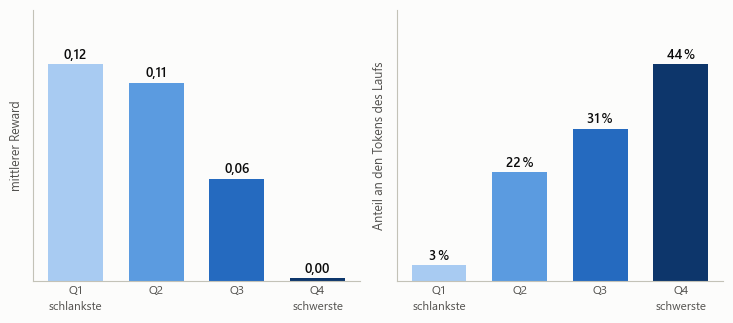

              mean_reward       tokens   n  share
quartile                                         
Q1\nleanest         0.124   12634040.0  24  0.031
Q2                  0.113   90026350.0  24  0.220
Q3                  0.058  126005814.0  24  0.308
Q4\nheaviest        0.001  180010696.0  24  0.440

            trials  median_tok  mean_reward
difficulty                                 
Easy            26   4612409.0       0.1312
Medium          46   4924890.0       0.0464
Hard            32   4763510.0       0.0487

Hard against Easy: median tokens x1.0, mean reward x0.37

tokens over the 96 trials that reported usage
  input     : 389M  (58% served from cache)
  output    : 19.6M
  requests  : 16,435 over all 104 trials
  total     : 408.7M  (8 trials have no usage recorded)


In [7]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.token_quartiles(df), "token-quartiles")
plt.show()

print(ja.token_quartile_table(df).round(3).to_string())
print()

levels = ja.by_difficulty(df)
print(levels.round(4).to_string())
print()
# Stated as a ratio in a fixed direction rather than as "more" or "less": not
# every arm consumes more on the harder half, and one of them consumes less.
tok = levels.median_tok["Hard"] / levels.median_tok["Easy"]
reward = levels.mean_reward["Hard"] / levels.mean_reward["Easy"]
print(f"Hard against Easy: median tokens x{tok:.1f}, mean reward x{reward:.2f}")

print()
print("tokens over the 96 trials that reported usage")
print(f"  input     : {df.in_tok.sum() / 1e6:.0f}M"
      f"  ({df.cache_tok.sum() / df.in_tok.sum():.0%} served from cache)")
print(f"  output    : {df.out_tok.sum() / 1e6:.1f}M")
print(f"  requests  : {int(df.requests.sum()):,} over all 104 trials")
print(f"  total     : {ja.fmt_tokens(df.total_tok.sum())}"
      f"  ({int(df.total_tok.isna().sum())} trials have no usage recorded)")

Aggregating the same consumption by what it produced gives the figure worth quoting.

wrote docs\figures\codes-tokens-by-outcome.png


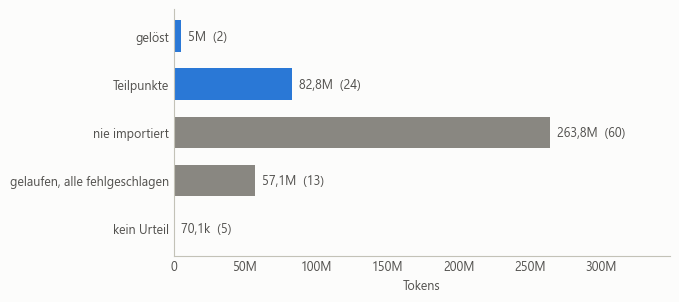

In [8]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.tokens_by_outcome(df), "tokens-by-outcome")
plt.show()

## 7. Which limit ended each run, and when

Three limits can stop this pipeline and they are three different findings, so the reader
should not have to take "did not finish" as one bucket. Two are the agent's own,
configured in `kwargs`: a **4M token budget** and a **2700-second wall clock**. The third
is the harness around it, which cancels an agent that has run for **3600 seconds**. A
fourth ending is not a limit at all — the process was signalled dead mid-request.

Telling them apart takes both the log and the harness's own exception, because the exit
status alone does not. A run stopped by either of its own budgets writes a
`BudgetExhausted` line and then exits 1, which is also what an ordinary crash looks like:
68 of the 104 trials carry `NonZeroAgentExitCodeError` at exit 1 and 64 of those are
simply the token budget doing its job. So `ending` is decided by the budget line the run
wrote about itself, and only where there is none does the exception decide.

Plotting each trial at the wall-clock time it stopped, against the two clocks drawn in,
says three things a table of counts cannot:

- **The token budget almost always bites first.** Sixty-four runs are spread across the
  whole time axis and stop well short of either clock — they run out of tokens, not time.
- **The agent's own wall clock overshoots.** The four trials it stopped ran 2713 to 3023
  seconds against a 2700-second limit, because the check only fires between requests and
  forty are in flight at once.
- **The harness deadline is a hard wall.** All six of its trials sit exactly on 3600
  seconds, and all six scored zero.

wrote docs\figures\codes-run-endings.png


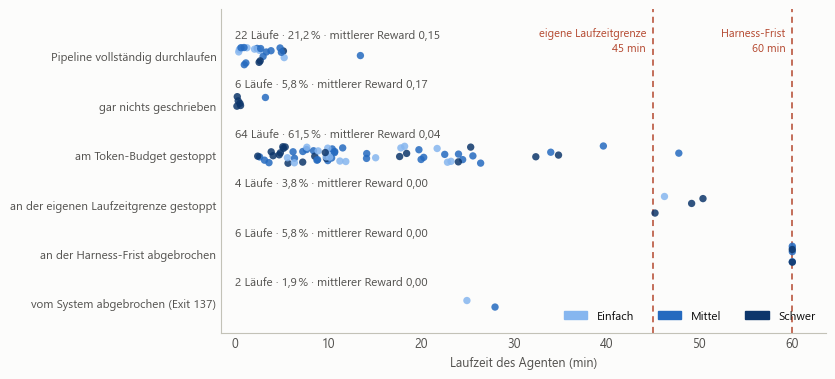

                                  n  mean_reward  median_seconds  median_queued  zeros  share
ending                                                                                       
finished the whole pipeline      22        0.147         156.197           70.0     11  0.212
wrote nothing at all              6        0.166          25.260            0.0      4  0.058
stopped at the token budget      64        0.045         616.726         1029.0     51  0.615
stopped at its own wall clock     4        0.000        2861.741         1949.0      4  0.038
stopped at the harness deadline   6        0.000        3600.009          438.5      6  0.058
killed by a signal                2        0.000        1588.287         3468.5      2  0.019

the agent's own limits : 2700s wall clock, 4,000,000 tokens
the harness deadline   : 3600s

stopped at its own wall clock   : ran 2713-3023s
stopped at the harness deadline : ran 3600-3600s

exit status against how the run actually ended
exit     

In [9]:
import numpy as np

df = ja.load_job(JOB, solved_at=SOLVED_AT)
t = TEXT["deaths"]

# Narrative order: the pipeline finishing, then the ways it did not.
ORDER = ["finished the whole pipeline", "wrote nothing at all",
         "stopped at the token budget", "stopped at its own wall clock",
         "stopped at the harness deadline", "killed by a signal"]
order = [e for e in ORDER if e in set(df.ending)]
own_clock = df.wall_clock_limit.iloc[0] / 60
deadline = df.harness_deadline.max() / 60
rng = np.random.default_rng(0)   # vertical jitter only

fig, ax = plt.subplots(figsize=(7.8, 4.2))
for i, ending in enumerate(order[::-1]):
    part = df[df.ending == ending]
    ax.scatter(
        part.t_agent / 60, i + rng.uniform(-0.18, 0.18, len(part)),
        s=28, color=[jf.BAND_COLOR[d] for d in part.difficulty],
        alpha=0.85, linewidth=0, zorder=3,
    )
    ax.annotate(
        t["row"].format(n=len(part), share=jf.percent(len(part) / len(df), 1),
                        reward=jf.num(part.reward.mean())),
        xy=(0, i + 0.30), color=jf.INK_2, fontsize=8.5, va="bottom",
    )

# The two clocks. Red is reserved for what a figure warns about, and these are
# the only marks here that are a constraint rather than an observation.
for limit, label in zip((own_clock, deadline), t["limits"]):
    ax.axvline(limit, color=jf.ALERT, linestyle=(0, (4, 3)), linewidth=1.1, zorder=2)
    ax.annotate(label.format(minutes=jf.num(limit, ".0f")),
                xy=(limit, len(order) - 0.42), xytext=(-5, 0),
                textcoords="offset points", ha="right", va="top",
                color=jf.ALERT, fontsize=8, linespacing=1.3)

jf.title(ax, t["title"])
ax.set_xlabel(t["x"])
ax.set_xlim(-1.5, deadline * 1.06)
ax.set_ylim(-0.6, len(order) - 0.05)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([jf.de(e) for e in order[::-1]], fontsize=8.5)
jf.tidy(ax, grid_axis="x")
jf.difficulty_legend(ax, loc="lower right")
save(fig, "run-endings")
plt.show()

table = df.groupby("ending").agg(
    n=("reward", "size"), mean_reward=("reward", "mean"),
    median_seconds=("t_agent", "median"), median_queued=("function_prompts", "median"),
    zeros=("reward", lambda s: int((s == 0).sum())))
table["share"] = table.n / len(df)
print(table.reindex(ORDER).dropna(how="all").round(3).to_string())
print()
print(f"the agent's own limits : {int(df.wall_clock_limit.iloc[0])}s wall clock,"
      f" {int(df.budget_value.iloc[0]):,} tokens")
print(f"the harness deadline   : {df.harness_deadline.max():.0f}s")
print()
for ending in ("stopped at its own wall clock", "stopped at the harness deadline"):
    part = df[df.ending == ending]
    if len(part):
        print(f"{ending:32s}: ran {part.t_agent.min():.0f}-{part.t_agent.max():.0f}s")
print()
# Exit 1 is the ordinary end of a budget-stopped run, so it cannot classify one.
print("exit status against how the run actually ended")
print(df.assign(exit=df.agent_exit.fillna(0).astype(int))
      .pivot_table(index="ending", columns="exit", values="reward", aggfunc="size")
      .fillna(0).astype(int).reindex(ORDER).dropna(how="all").to_string())

## 8. Why each zero was a zero

"Scored nothing" is not a diagnosis. The verifier writes a full pytest report for every
trial, and that report names the exception that stopped the run — so each zero can be
given the technical reason it earned, read from its own output rather than assigned by
hand. `ja.classify_zero` does this identically for every arm.

Each zero gets a **stage** and a **cause**. The stage is how far the pipeline got:

| Stage | Meaning |
| --- | --- |
| `never configured` | pytest refused to start — unparsable `pyproject.toml`, a config option needing a plugin that is not installed, an incompatible plugin, or no tests collected at all |
| `never imported` | pytest started, and the generated code failed to import |
| `ran, all failed` | the code imported, the tests executed, and every one of them failed |
| `no verdict` | the tester never produced a real judgement — a harness fault, not a finding about the code |

The cause is the exception itself. Two of them are refined further, because the
exception name on its own hides the mistake:

- **`ModuleNotFoundError`** is four different errors. *Own code, wrong layout* — the
  file is in the workspace, but not importable under the name its own code uses.
  *A file it never wrote* — the package is there, the module it imports is not.
  *Uninstalled dependency* — a third-party library the agent assumed would be present.
  *Project built one level too deep* — the whole project sits inside a single
  sub-directory of the workspace. Which one is decided by looking the missing name up
  against everything the agent actually wrote, as a dotted path resolved against both
  import roots and, failing that, against a nested project root.
- **`ImportError`** is three more: a *circular import*; a name *missing from its own
  module*; and a name *gone from an installed module*, which means the code was written
  against an API the installed version does not have.

Where one report holds several exceptions, the cause is the one raised most often — the
error blocking most of the suite, not whichever pytest printed first.

One thing to keep in mind reading this figure: a pipeline stopped at its token budget
leaves a repository that is *partly written* — the files the filler reached are complete
and the rest still hold their unfilled skeletons. Most of the causes below are what a
half-written package does when something tries to import it, which is a different
finding from a package that was written wrongly.

wrote docs\figures\codes-zero-causes.png

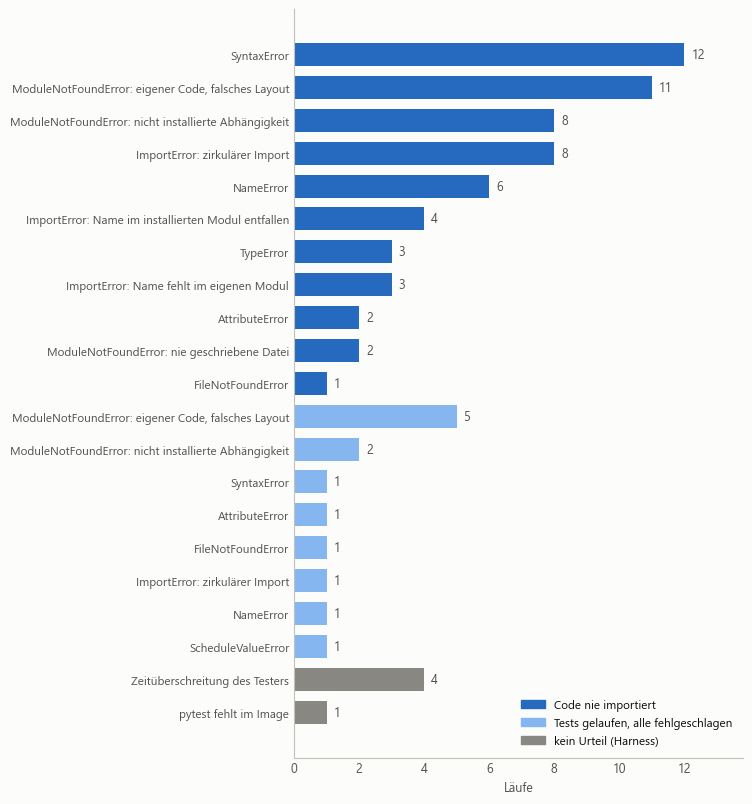

fault_stage
never configured     0
never imported      60
ran, all failed     13
no verdict           5


In [10]:
df = ja.load_job(JOB, solved_at=SOLVED_AT)

save(jf.zero_causes(df), "zero-causes")
plt.show()

zeros = df[df.scored & (df.reward == 0)]
print(zeros.fault_stage.value_counts().reindex(ja.STAGES).fillna(0).astype(int).to_string())

The task behind each row is worth having to hand when reading the figure, so the full
list is printed below, with where each run stopped beside it.

In [11]:
import pandas as pd

df = ja.load_job(JOB, solved_at=SOLVED_AT)
zeros = df[df.scored & (df.reward == 0)]

table = (zeros[["task", "difficulty", "fault_stage", "fault_cause",
                "ending", "function_prompts"]]
         .sort_values(["fault_stage", "fault_cause", "task"])
         .reset_index(drop=True))
with pd.option_context("display.max_rows", None, "display.width", 210,
                       "display.max_colwidth", 44):
    print(table.to_string())

                     task difficulty      fault_stage                                      fault_cause                           ending  function_prompts
0                 ipytest       Easy   never imported                                   AttributeError    stopped at its own wall clock              2258
1                 stamina     Medium   never imported                                   AttributeError      stopped at the token budget               454
2               synthetic       Hard   never imported                                FileNotFoundError      stopped at the token budget              1231
3               freezegun     Medium   never imported                     ImportError: circular import      stopped at the token budget              2592
4                 justext       Easy   never imported                     ImportError: circular import      stopped at the token budget              1794
5                  mootdx       Hard   never imported                     Im

## 9. Two checks on the numbers above

**The reward is what it claims to be.** Reward arrives as a single float in
`result.json`, computed inside the container by a tester this notebook never sees. It
should be the fraction of hidden tests that passed, and pytest's own summary line —
parsed independently, out of a different file — agrees with it closely. The residual
gap is that pytest counts a collection error as one unit where the tester counts the
tests it would have contained.

**Every zero was classified, and none was left over.** A zero the classifier could not
read would be filed as `unclassified`, and the count of those is printed below, so that
a silent gap in the taxonomy cannot pass as a clean result.

In [12]:
import pandas as pd

df = ja.load_job(JOB, solved_at=SOLVED_AT)

ran = df[df.scored & df.pt_ran].copy()
units = (ran.pt_passed + ran.pt_failed + ran.pt_error).replace(0, pd.NA)
ran["pytest_fraction"] = ran.pt_passed / units
agree = ran.dropna(subset=["pytest_fraction"])

print("reward against pytest's own pass fraction")
print(f"  trials compared : {len(agree)} of {int(df.scored.sum())} scored"
      f" ({int(df.scored.sum()) - len(ran)} excluded, pytest never reached a summary)")
print(f"  correlation     : r = {agree.reward.corr(agree.pytest_fraction):.3f}")
print(f"  median gap      : {(agree.reward - agree.pytest_fraction).abs().median():.3f}")
print()

zeros = df[df.scored & (df.reward == 0)]
print(f"unclassified zeros: {int((zeros.fault_cause == 'unclassified').sum())} of {len(zeros)}")
print()
print("how the run stopped, and what each way scored")
print(df.groupby("ending").agg(
    trials=("reward", "size"), mean_reward=("reward", "mean"),
    zeros=("reward", lambda s: int((s == 0).sum()))).round(3).to_string())

reward against pytest's own pass fraction
  trials compared : 78 of 104 scored (26 excluded, pytest never reached a summary)
  correlation     : r = 0.962
  median gap      : 0.000

unclassified zeros: 0 of 78

how the run stopped, and what each way scored
                                 trials  mean_reward  zeros
ending                                                     
finished the whole pipeline          22        0.147     11
killed by a signal                    2        0.000      2
stopped at its own wall clock         4        0.000      4
stopped at the harness deadline       6        0.000      6
stopped at the token budget          64        0.045     51
wrote nothing at all                  6        0.166      4


## What this run says

- **The pipeline rarely finishes, and mostly scores nothing.** Mean reward 0.07, median
  0, with 78 of 104 trials at exactly zero and two above 0.9. Seventy-six runs never
  reached the end of their own pipeline.
- **The token budget is what stops it**, in 64 of those 76 — not the wall clock, and not
  the model refusing. Four more hit the wall-clock limit and eight were killed by the
  harness around them.
- **The decomposition decides the outcome, and the task does not decide the
  decomposition.** Runs that finished had queued a median of 54 function bodies; runs
  stopped at the budget, 1,029. Yet the number queued is essentially uncorrelated with
  the size of the specification or the count of hidden tests, and the completion rate is
  flat across Easy, Medium and Hard. Whether a run can afford itself is settled by the
  RepoSketcher's own choice, before any code is written.
- **It is by far the heaviest arm to run** — 408.7M tokens across the 96 trials that
  reported usage, and that is a floor, since eight trials recorded none. Its 19.6M output
  tokens are more than the other three arms produce put together. One request per function
  body with no feedback loop means those tokens are spent whether or not the result
  imports.
- **Consumption is flat across difficulty.** Easy and Hard trials burn near-identical
  volumes, because almost every run spends its whole budget whatever the task was. The
  apparent cost inversion in an earlier draft of this notebook was a pricing artefact and
  not a property of the run; it does not survive being counted in tokens.
- **One task in the benchmark is not measuring anything.** `more-Itertools` scores 0.978
  against an empty workspace, because its hidden tests import the library installed in
  the image rather than the code under test. It should be excluded, or its tester fixed,
  before any arm is scored on it.
- **Most zeros are half-written packages, not wrong ones.** The largest group by far is
  code that never imported, which is what a repository looks like when the filler was
  stopped partway through it. Reading those as "the model got the code wrong" would
  misattribute a budget failure to a reasoning one.